In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
df_train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')

In [56]:
df_train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [57]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [58]:
df_train = df_train.drop('id', axis=1)

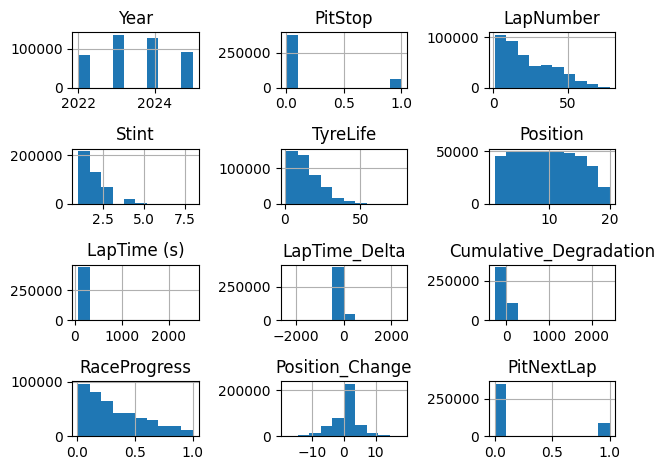

In [59]:
df_train.hist()
plt.tight_layout()

In [60]:
X = df_train.drop('PitNextLap', axis=1)
y = df_train['PitNextLap']

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

In [64]:
model = CatBoostClassifier(
    iterations=200, 
    verbose=False,
    loss_function='Logloss'
)

In [65]:
params = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

In [66]:
final_model = RandomizedSearchCV(
    estimator=model,
    param_distributions=params,
    n_iter=10,           
    cv=2,
    scoring='f1',
)

In [67]:
str_columns = ['Driver', 'Compound', 'Race']

In [68]:
final_model.fit(X_train,y_train, cat_features = str_columns)

RandomizedSearchCV(cv=2,
                   estimator=CatBoostClassifier(iterations=200, loss_function='Logloss', verbose=False),
                   param_distributions={'depth': [4, 6, 8],
                                        'l2_leaf_reg': [1, 3, 5],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   scoring='f1')

In [77]:
y_pred = final_model.predict(X_test)

In [78]:
accuracy_score(y_test, y_pred)

0.8947032836908503

In [79]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93     70286
         1.0       0.75      0.72      0.73     17542

    accuracy                           0.89     87828
   macro avg       0.84      0.83      0.83     87828
weighted avg       0.89      0.89      0.89     87828



In [80]:
import pickle 

In [82]:
with open('F1Classification_model.pkl', 'wb') as f:
    pickle.dump(final_model.best_estimator_, f)

In [83]:
best_cb = final_model.best_estimator_

In [96]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_cb.get_feature_importance()
}).sort_values(by='importance', ascending=True)

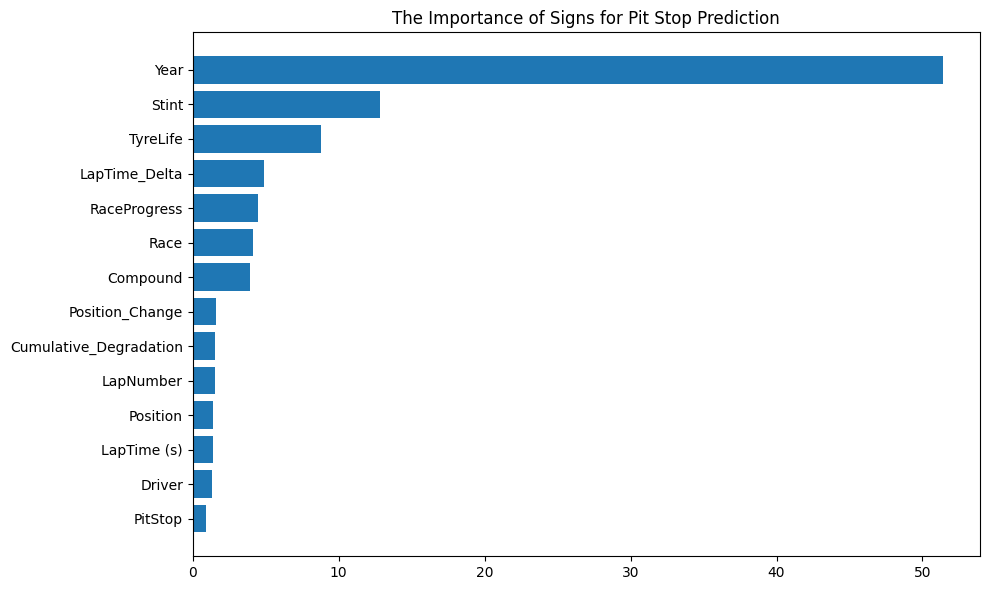

In [100]:
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'])
plt.title('The Importance of Signs for Pit Stop Prediction')
plt.tight_layout()
plt.show()